In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("../data/processed/ecommerce_master_dataset.csv")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350.0,maua,SP,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,31570.0,belo horizonte,SP,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,14840.0,guariba,SP,1.0,credit_card,3.0,179.12


In [5]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

In [6]:
customer_orders = df.groupby("customer_unique_id")["order_id"].nunique()

customer_orders.head()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
Name: order_id, dtype: int64

In [7]:
customer_orders.value_counts().sort_index()

order_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [8]:
df["payment_type"].value_counts()

payment_type
credit_card    87286
boleto         23037
voucher         6407
debit_card      1698
not_defined        3
Name: count, dtype: int64

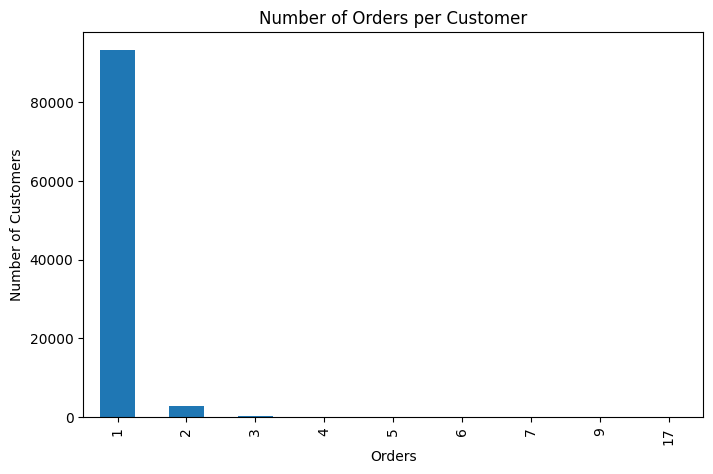

In [9]:
plt.figure(figsize=(8,5))
customer_orders.value_counts().sort_index().plot(kind="bar")

plt.title("Number of Orders per Customer")
plt.xlabel("Orders")
plt.ylabel("Number of Customers")

plt.show()

In [10]:
customer_clv = df.groupby("customer_unique_id")["payment_value"].sum()

customer_clv.head()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    141.90
0000b849f77a49e4a4ce2b2a4ca5be3f     27.19
0000f46a3911fa3c0805444483337064     86.22
0000f6ccb0745a6a4b88665a16c9f078     43.62
0004aac84e0df4da2b147fca70cf8255    196.89
Name: payment_value, dtype: float64

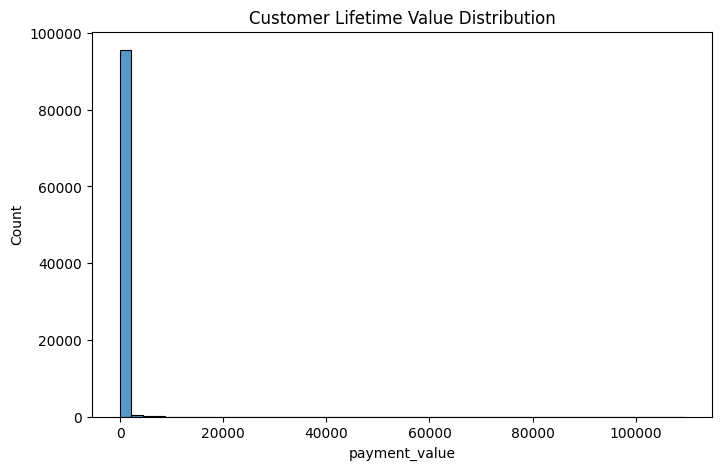

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(customer_clv, bins=50)

plt.title("Customer Lifetime Value Distribution")

plt.show()

In [12]:
customer_clv.sort_values(ascending=False).head(10)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    109312.64
698e1cf81d01a3d389d96145f7fa6df8     45256.00
c402f431464c72e27330a67f7b94d4fb     44048.00
4007669dec559734d6f53e029e360987     36489.24
ef8d54b3797ea4db1d63f0ced6a906e9     30186.00
763c8b1c9c68a0229c42c9fc6f662b93     29099.52
c8460e4251689ba205045f3ea17884a1     27935.46
eae0a83d752b1dd32697e0e7b4221656     25051.89
3d47f4368ccc8e1bb4c4a12dbda7111b     22346.60
adfa1cab2b2c8706db21bb13c0a1beb1     19457.04
Name: payment_value, dtype: float64

In [13]:
df.to_csv("../data/processed/ecommerce_dashboard_dataset.csv", index=False)